In [1]:
import os
import echopype as ep
import matplotlib.pyplot as plt
import datetime
import numpy as np
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
#USE echopype_env on oceanica_joan folder!

#NOTES:
#.bot files for EK60 sonars are not used by echpype, not implemented
#dades de EK80?
#deadline fins després de sermana santa per jugar
# del 7 al 16 d'abril 

In [2]:
#FileName = 'D20110113-T105327'
#FileName = 'D20110113-T105327'
#rawFileDate = datetime.datetime(int(FileName[1:5]), int(FileName[5:7]), int(FileName[7:9]))
#dates = ['D20110113-T', 'D20110112-T', 'D20110111-T', 'D20110110-T', 'D20110109-T', 'D20110108-T']
dates = [ 'D20110113-T', 'D20110112-T']

D20110113-T
getting raw 57 files...
raw files opened
combining data...
computing SV...
adding depth...
cleaning noise...
adding location and exporting...


C:\Users\jsala\AppData\Local\Temp\ipykernel_22400\772561529.py:67: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(


Text(0, 0.5, 'Depth (m)')

Text(0.5, 0, 'Ping time (UTC)')

Text(0.5, 1.0, '13-01-2011 - EK60 Sv GPT  38 kHz 009072055bb4 1-1 ES38B')

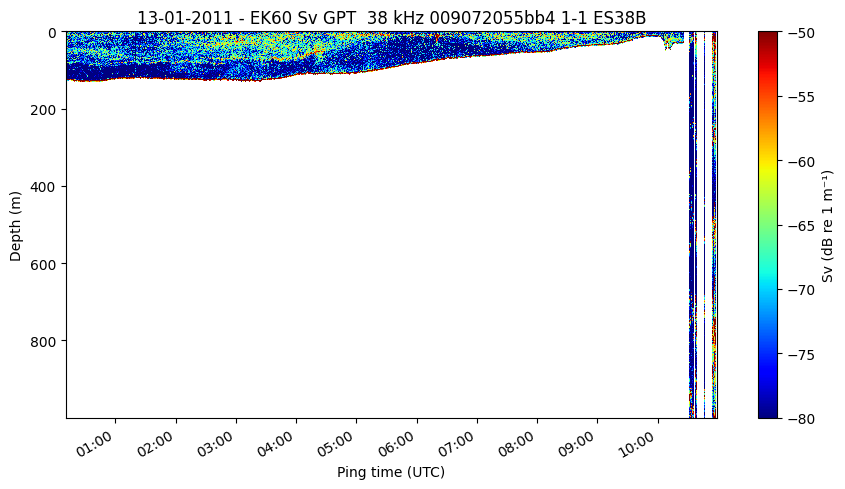

D20110112-T
getting raw 91 files...
raw files opened
combining data...
computing SV...
adding depth...
cleaning noise...
adding location and exporting...


Text(0, 0.5, 'Depth (m)')

Text(0.5, 0, 'Ping time (UTC)')

Text(0.5, 1.0, '12-01-2011 - EK60 Sv GPT  38 kHz 009072055bb4 1-1 ES38B')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import echopype as ep
import echopype.colormap  # registers the "ep.ek500" colormap
for date in dates:
    print(date)
    #extract raw file names for that date
    FileNames = [
        f for f in os.listdir('../data/MALASPINA_LEG1/')
        if date in f and '.raw' in f]
    
    #get a list of all the converted raw files into EchoData objects
    print('getting raw ' + str(len(FileNames)) + ' files...')
    ed_list = []
    for FileName in FileNames:
        ed = ep.open_raw("../data/MALASPINA_LEG1/" + FileName, include_bot=True, sonar_model="EK60")  # for EK60 file
        ed_list.append(ed)
        del ed
    print('raw files opened')
    
    print('combining data...')
    ed_cons = ep.combine_echodata(ed_list)
    # ── 2. Calibrate (CW / power mode for EK60) ──────────────────────────────────
    print('computing SV...')
    ds_Sv = ep.calibrate.compute_Sv(ed_cons, waveform_mode="CW", encode_mode="power")

    # ── 3. Add depth as a coordinate ──────────────────────────────────────────────
    print('adding depth...')
    ds_Sv = ep.consolidate.add_depth(ds_Sv)
    
    detected_seafloor = ed_cons["Vendor_specific"]["detected_seafloor_depth"]
    depth_3d = ds_Sv["depth"]
    water_column_mask = depth_3d < detected_seafloor
    ds_Sv["Sv"] = ds_Sv["Sv"].where(water_column_mask)

    ds_Sv = ds_Sv.assign_coords(depth=ds_Sv["depth"].mean(dim="ping_time"))

    #5. remove_noise
    print('cleaning noise...')
    ds_Sv = ep.clean.remove_background_noise(    # obtain a denoised Sv dataset
    ds_Sv,                # calibrated Sv dataset
    range_sample_num=30,  # number of samples along the range_sample dimension for estimating noise
    ping_num=5,           # number of pings for estimating noise
    )
    
    #6.Export coordinates
    print('adding location and exporting...')
    ds_Sv = ep.consolidate.add_location(ds_Sv, ed_cons)
    ds_Sv[['latitude', 'longitude']].to_dataframe().to_csv('../data/coords/'+date+'_2.csv')
    
    ##
    # Extract arrays
    sv = ds_Sv["Sv"].sel(channel=ds_Sv["channel"][0])
    ping_time = sv["ping_time"].values        # shape (Npings,)
    depth = ds_Sv["depth"].values             # shape (Ndepth,)
    sv_data = sv.values                       # shape (Npings, Ndepth)

    # Transpose to (Ndepth, Npings)
    sv_T = sv_data.T                          # now shape (Ndepth, Npings)

    # Build coordinate grids
    PING, DEPTH = np.meshgrid(ping_time, depth)

    # Plot
    fig, ax = plt.subplots(figsize=(9, 5))

    pcm = ax.pcolormesh(
        PING,
        DEPTH,
        sv_T,
        cmap="jet",
        vmin=-80,
        vmax=-50,
        shading="auto"
    )

    ax.invert_yaxis()
    ax.set_ylabel("Depth (m)")
    ax.set_xlabel("Ping time (UTC)")
    ax.set_title(date[7:9] + '-' + date[5:7] + '-' + date[1:5] + " - EK60 Sv " + str(ds_Sv['channel'].values[0]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

    plt.gcf().autofmt_xdate(rotation=30)

    # Colorbar
    fig.colorbar(pcm, ax=ax, label="Sv (dB re 1 m⁻¹)")

    plt.tight_layout()
    plt.savefig('../data/echograms/' + date + '_bot.png', dpi=300, bbox_inches="tight")
    plt.show()
